# Term Project Milestone 1: Data Selection and EDA

**Dataset:** Netflix Titles

**Date:** 2026-02-01


### Milestone 1 

Streaming platforms compete on both content growth and viewer trust. The operational business faces its primary challenge because it needs to protect content while ensuring children stay safe and providing correct recommendations to adult viewers. Content teams also need to understand how the catalog changes over time especially whether additions are skewing toward adult ratings.

The research investigates a practical business problem which Netflix and similar streaming platforms need to solve about title maturity prediction through early content pipeline metadata including type and genres and country and additional information. A platform which detects mature content at its onset can perform three functions: it will direct content for human assessment and it will adjust parental control settings through advanced methods and it will enhance content recommendations for families who watch different types of content.

The dataset for this milestone is the public Netflix titles catalog. Milestone 1 is about choosing the target and learning what the data is telling us before modeling. The target variable for future milestones will be a binary flag named is_mature which we will define as titles that receive TV-MA, R or NC-17 ratings because these represent adult-only content categories. Everything else is treated as not mature. The definition provides a simple way to explain the target which matches the functionality of parental control systems.

The graphical analysis from this milestone begins to provide solutions for the main research questions about title maturity prevalence in the catalog. How has Netflix’s catalog grown over time?Do Movies and TV Shows differ in mature share?And which common genres have higher mature proportions?The identified patterns reveal which variables will become important features in the future analysis (the patterns show that exploding genres and using year added and treating type as a key predictor will be useful).

### Significance and Intended Use of This Model (Why this matters)

In this project, I am building a model that predicts whether a Netflix title is **mature content** using the title’s **metadata** (for example: type, release year, duration, country, cast/director fields, genres, and description patterns). The significance is that this model can support a **human‑in‑the‑loop** content workflow when a platform adds new titles or imports large catalogs. Instead of relying only on manual review, my model can quickly **flag** titles that are likely mature so that reviewers can prioritize them for faster screening and quality checks. This can improve speed and consistency when the catalog changes frequently. This model is **not meant to replace official ratings**; it is a decision‑support tool that helps humans work more efficiently.

**How I would use the model:**
1. **Pre‑screening new or unrated titles:** If a new title is missing an official rating at ingestion time, I can use the model to estimate whether it is likely mature and route it to the appropriate review queue.
2. **Quality assurance / auditing:** I can flag titles where the metadata strongly suggests mature themes but the label appears non‑mature (or vice versa). Those cases can be checked by a reviewer to catch mislabeling, missing tags, or inconsistencies in catalog metadata.
3. **Parental control support:** I can use the model as an additional safeguard to reduce the chance that mature titles appear in family‑friendly browsing contexts (while keeping humans and official policy rules as the final authority).

**What “success” looks like (how I will evaluate usefulness):**
- If the goal is to catch most mature titles, I will prioritize **recall** (so fewer mature titles slip through).
- If the goal is to avoid overwhelming reviewers, I will also monitor **precision** (so the flagged list is not mostly wrong).
- I will report a **confusion matrix** and summary metrics such as **F1 score** (and/or ROC‑AUC) to balance these goals.

**Important modeling constraint (avoiding data leakage / data snooping):**
The Netflix `rating` is strongly related to maturity. If I use `rating` as an input feature while also using it to define my target label, that would create **data leakage** and an unrealistic model. Therefore, I will use `rating` **only to create the target label** (mature vs not mature) and I will **exclude `rating` from the feature set** during model training and evaluation.


## Setup + Data Load

The code below loads the dataset from the uploaded ZIP, cleans column names, parses dates, and creates the **is_mature** target flag (TV-MA/R/NC-17).

In [1]:
# =============================
# Setup + Data Load (NO ERRORS)
# =============================
# Put your data file in the SAME folder as this notebook.
# Accepts either:
#   1) netflix_titles.csv
#   2) a ZIP that contains the CSV (ex: netflix_titles.zip)
#
# If your file has a different name, set DATA_PATH below.

import os
import glob
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Option 1: set this if you want to be explicit ----
# DATA_PATH = r"netflix_titles.csv"   # <-- change if needed
DATA_PATH = None  # leave as None to auto-detect

# ---- Auto-detect file in the same folder as this notebook ----
# In Jupyter, current working directory is usually the notebook's folder.
cwd = os.getcwd()

def pick_data_file(folder: str) -> str:
    """Find a Netflix titles CSV or ZIP in the given folder."""
    # Try CSV first
    csv_matches = sorted(glob.glob(os.path.join(folder, "*netflix*title*.csv"))) +                   sorted(glob.glob(os.path.join(folder, "*.csv")))
    if csv_matches:
        return csv_matches[0]

    # Then try ZIP
    zip_matches = sorted(glob.glob(os.path.join(folder, "*netflix*title*.zip"))) +                   sorted(glob.glob(os.path.join(folder, "*.zip")))
    if zip_matches:
        return zip_matches[0]

    raise FileNotFoundError(
        "I couldn't find a CSV or ZIP in this folder.\n"
        "Fix: Put your dataset file in the SAME folder as this notebook, then run again.\n"
        "Or set DATA_PATH to the exact filename."
    )

path = DATA_PATH if DATA_PATH else pick_data_file(cwd)
print("Found data file:", path)

# ---- Load (CSV or ZIP) ----
if path.lower().endswith(".zip"):
    extract_dir = os.path.join(cwd, "netflix_extract")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(path, "r") as z:
        z.extractall(extract_dir)

    csv_inside = sorted(glob.glob(os.path.join(extract_dir, "**", "*.csv"), recursive=True))
    if not csv_inside:
        raise FileNotFoundError("ZIP opened, but no CSV was found inside it.")
    csv_path = csv_inside[0]
else:
    csv_path = path

print("Using CSV:", csv_path)
df = pd.read_csv(csv_path)

# Clean column names for easier coding
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Parse date_added (used for titles added per year)
df["date_added_parsed"] = pd.to_datetime(df.get("date_added"), errors="coerce")
df["added_year"] = df["date_added_parsed"].dt.year

# Define target: mature (adult-only) ratings
adult_ratings = {"TV-MA", "R", "NC-17"}
df["is_mature"] = df["rating"].isin(adult_ratings).astype(int)

# Quick look
display(df.head())
print("\nRows:", df.shape[0], " | Columns:", df.shape[1])
print("\nRating value counts (top 10):")
print(df["rating"].value_counts().head(10))


Found data file: C:\Users\adjov\gg\week 8\week 7  and 8 540 class\milestone 3\Mileston 4\550\excercice\540\milestone 5\550\netflix_titles (1).csv
Using CSV: C:\Users\adjov\gg\week 8\week 7  and 8 540 class\milestone 3\Mileston 4\550\excercice\540\milestone 5\550\netflix_titles (1).csv


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_parsed,added_year,is_mature
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-14,2020.0,1
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016-12-23,2016.0,1
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018-12-20,2018.0,1
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017-11-16,2017.0,0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020-01-01,2020.0,0



Rows: 7787  | Columns: 15

Rating value counts (top 10):
rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64


## Graph 1 — Mature vs Not Mature (Target Balance)

**What this shows:** How many titles fall into the mature group versus not mature.

**Why it matters:** If mature titles are a smaller share of the catalog, later modeling can suffer from class imbalance. That means we should not rely on accuracy alone; precision/recall and threshold tuning become important.

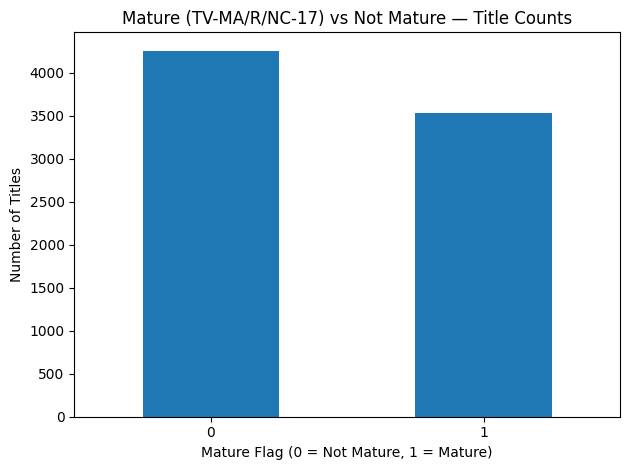

In [2]:
assert 'df' in globals(), "Run the Setup + Data Load cell first (it creates df)."
# Graph 1: Mature vs Not Mature counts
mature_counts = df["is_mature"].value_counts().sort_index()

plt.figure()
mature_counts.plot(kind="bar")
plt.title("Mature (TV-MA/R/NC-17) vs Not Mature — Title Counts")
plt.xlabel("Mature Flag (0 = Not Mature, 1 = Mature)")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Graph 2 — Titles Added by Year

**What this shows:** How many titles were added to Netflix each year.

**Why it matters:** This gives context for catalog growth and helps us see whether the dataset is skewed toward recent additions (which affects how we interpret patterns).

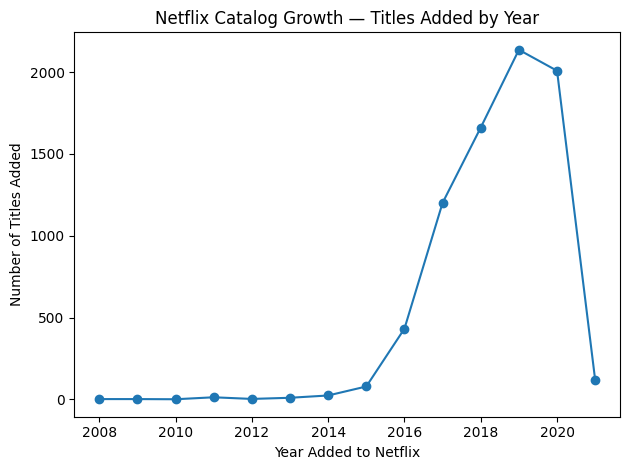

In [3]:
assert 'df' in globals(), "Run the Setup + Data Load cell first (it creates df)."
# Graph 2: Titles added by year
added_by_year = df.dropna(subset=["added_year"]).groupby("added_year").size().sort_index()

plt.figure()
plt.plot(added_by_year.index, added_by_year.values, marker="o")
plt.title("Netflix Catalog Growth — Titles Added by Year")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()


## Graph 3 — Mature Share by Content Type (Movie vs TV Show)

**What this shows:** The percentage of mature titles within Movies versus TV Shows.

**Why it matters:** If one type consistently has higher mature share, that’s both a strong feature for prediction and useful operational insight for content strategy and parental controls.

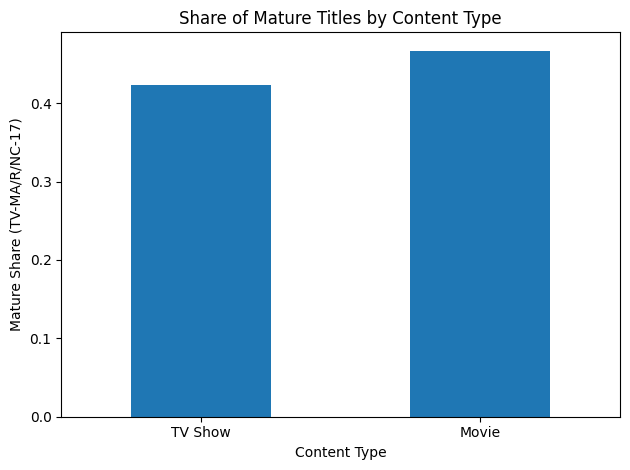

In [4]:
assert 'df' in globals(), "Run the Setup + Data Load cell first (it creates df)."
# Graph 3: Mature share by type
mature_rate_by_type = df.groupby("type")["is_mature"].mean().sort_values()

plt.figure()
mature_rate_by_type.plot(kind="bar")
plt.title("Share of Mature Titles by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Mature Share (TV-MA/R/NC-17)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Graph 4 — Mature Share by Genre (Top 10 Most Common Genres)

**What this shows:** Mature share for the 10 most common genres based on `listed_in` tags.

**Why it matters:** Genre tags are available early and often carry strong signal. In later milestones, we can encode genres (multi-hot) to improve a mature-content classifier.

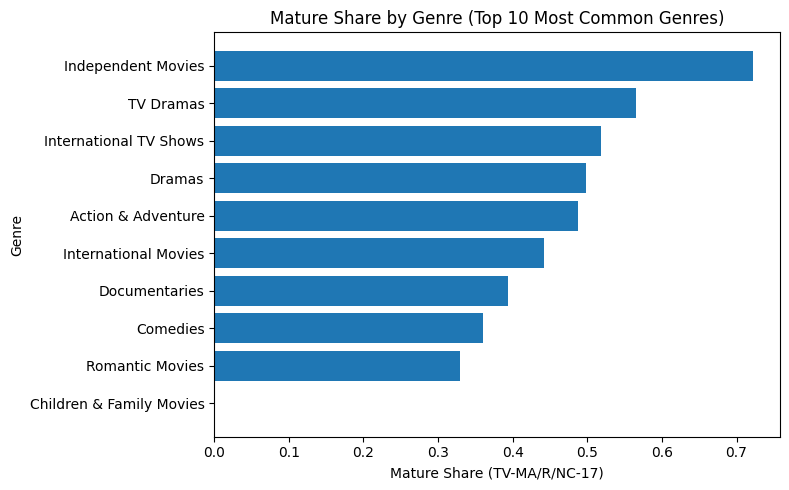

,titles,mature_share
genre,,
Children & Family Movies,532,0.000000
Romantic Movies,531,0.329567
Comedies,1471,0.359619
Documentaries,786,0.394402
International Movies,2437,0.441937
Action & Adventure,721,0.488211
Dramas,2106,0.497626
International TV Shows,1199,0.518766
TV Dramas,704,0.565341


In [5]:
assert 'df' in globals(), "Run the Setup + Data Load cell first (it creates df)."
# Graph 4: Mature share by genre (top 10 most common)
df_genres = df[["show_id", "listed_in", "is_mature"]].dropna().copy()
df_genres["genre"] = df_genres["listed_in"].str.split(", ")
df_genres = df_genres.explode("genre")
df_genres["genre"] = df_genres["genre"].str.strip()
df_genres = df_genres[df_genres["genre"] != ""]

top10 = df_genres["genre"].value_counts().head(10).index

genre_stats = (df_genres[df_genres["genre"].isin(top10)]
               .groupby("genre")
               .agg(titles=("show_id", "count"), mature_share=("is_mature", "mean"))
               .sort_values("mature_share"))

plt.figure(figsize=(8, 5))
plt.barh(genre_stats.index, genre_stats["mature_share"].values)
plt.title("Mature Share by Genre (Top 10 Most Common Genres)")
plt.xlabel("Mature Share (TV-MA/R/NC-17)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

display(genre_stats)


## Overview / Conclusion 

The visual data shows that Netflix has many adult-oriented content titles but these titles do not lead the most popular content so it seems possible to predict mature content through classification. The "titles added by year" pattern shows that the catalog expanded its collection most heavily during the previous few years which should be taken into account when studying rating pattern changes. The data shows that Mature share rates between Movies and TV Shows differ which suggests that the content type (type) variable has a significant impact. The most common genres show different mature proportion patterns which support the development of genre features for future modeling work (the `listed_in` field should be split into separate genre indicators).


# Milestone 2 begins here — Data Preparation

Everything above this header is my **Milestone 1 (EDA + project framing)**.  
Everything below is **Milestone 2 (Data Preparation)**.

In Milestone 2, I prepare the dataset so it is ready for model training/evaluation in Milestone 3.


# Term Project — Milestone 2: Data Preparation (Netflix Mature Content)

In this milestone, I take the raw Netflix titles dataset and **prepare it for model building**. My goal is to end Milestone 2 with:

- a clearly-defined target (**what I’m predicting**),
- a cleaned feature set (**what I’m using to predict**),
- a documented missing-data strategy,
- and a preprocessing pipeline that is **safe from data snooping**.

## Why this model matters (significance / intended use)

I am building a model that predicts whether a title is likely **mature content** *using metadata* (type, year, genres, duration, country, and lightweight text signals). I would use this model as a **decision-support tool** (human-in-the-loop), for example:

- **Pre-screening:** flag titles that likely need mature labeling review when metadata is incomplete or inconsistent.
- **Quality checks:** identify potential mislabels or unusual cases for audit (titles that “look mature” from metadata but are labeled otherwise).
- **Catalog operations:** help prioritize manual review efforts by ranking titles by predicted maturity risk.

**Important limitation (and why it’s okay):** this model does *not* watch the content. It uses available metadata, so predictions are probabilistic and should support—not replace—official rating processes.

## Milestone 2 requirements (how I meet them)

I explicitly document each of the following in this notebook:
1. Dropping features that are not useful for modeling (with justification)
2. Data extraction/selection decisions
3. Feature transformations (types / parsing)
4. Feature engineering (creating new useful features)
5. Missing-data handling (not blindly dropping rows/columns)
6. Dummy variables / encoding (for categorical and multi-label text)
7. **Avoiding data snooping:** I split train/test **before** fitting preprocessing, and I fit transforms **only** on training data.


In [6]:
# In this setup cell, I import the libraries I will use for cleaning, feature engineering, and preprocessing.
# I am not training a model yet; I am only preparing model-ready data.

# =========================
# 0) Setup
# =========================
import os
import glob
import zipfile
import pandas as pd
import numpy as np

from pathlib import Path

# Modeling-safe preprocessing tools (Milestone 3 will train models; here we prepare data safely)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


## 1) Load data (self-contained)

In this step, I load my dataset into a pandas DataFrame called `df`.

### What I’m expecting
For the common Netflix titles dataset (often named something like `netflix_titles.csv`), I expect columns similar to:
`show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description`

**Checkpoint:** after loading, I display `df.shape` and `df.head()` so I can confirm the data looks correct before cleaning.


In [7]:
from IPython.display import display

# I reuse the dataset loaded in Milestone 1 whenever possible.
# This prevents me from accidentally loading a different file or changing the data between milestones.

if "df" in globals() and isinstance(df, pd.DataFrame):
    print("Reusing df loaded in Milestone 1.")
    print("Shape:", df.shape)
    display(df.head())
else:
    # If df is not already defined, I fall back to the self-contained loader below.
    # (This keeps the combined notebook runnable even if someone runs Milestone 2 first.)
    # In this cell, I load the dataset into a DataFrame called df.
    # I support both CSV and ZIP inputs so the notebook is easy to run and re-run.
    # After loading, I print shape and preview the first rows to confirm the data loaded correctly.

    # ---- Option 1: set this if you want to be explicit ----
    # DATA_PATH = r"netflix_titles.csv"   # <-- change if needed
    DATA_PATH = None  # leave as None to auto-detect

    def load_netflix_file(data_path=None):
        # If user set a path explicitly
        if data_path is not None:
            p = Path(data_path)
            if not p.exists():
                raise FileNotFoundError(f"Cannot find file: {p.resolve()}")
            if p.suffix.lower() == ".csv":
                return pd.read_csv(p)
            if p.suffix.lower() == ".zip":
                with zipfile.ZipFile(p, "r") as z:
                    csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
                    if not csvs:
                        raise ValueError("ZIP file does not contain a CSV.")
                    with z.open(csvs[0]) as f:
                        return pd.read_csv(f)
            raise ValueError("Unsupported file type. Use .csv or .zip")

        # Auto-detect in current folder
        candidates = []
        candidates += glob.glob("netflix_titles.csv")
        candidates += glob.glob("*.csv")
        candidates += glob.glob("*.zip")

        if not candidates:
            raise FileNotFoundError("No .csv or .zip found in this folder. Put your dataset next to this notebook.")

        # Prefer exact expected filename
        if "netflix_titles.csv" in candidates:
            return pd.read_csv("netflix_titles.csv")

        # Otherwise pick first candidate (you can change this if needed)
        pick = candidates[0]
        print("Auto-detected file:", pick)
        if pick.lower().endswith(".csv"):
            return pd.read_csv(pick)
        else:
            with zipfile.ZipFile(pick, "r") as z:
                csvs = [n for n in z.namelist() if n.lower().endswith(".csv")]
                if not csvs:
                    raise ValueError("ZIP file does not contain a CSV.")
                with z.open(csvs[0]) as f:
                    return pd.read_csv(f)

    df = load_netflix_file(DATA_PATH)
    print("Shape:", df.shape)
    df.head()


Reusing df loaded in Milestone 1.
Shape: (7787, 15)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_parsed,added_year,is_mature
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020-08-14,2020.0,1
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016-12-23,2016.0,1
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018-12-20,2018.0,1
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017-11-16,2017.0,0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020-01-01,2020.0,0


## 2) Quick audit (types, duplicates, missingness)

Before I change anything, I do a quick audit so my decisions are **evidence-based**.

### What I check (and why)
- **Data types (`df.info()`)**: I need to know what is numeric vs categorical vs date-like.
- **Exact duplicates**: duplicates can bias the model by repeating the same examples.
- **Missingness rates**: I use missingness patterns to decide whether to impute, engineer “missing flags,” or drop a feature (only if justified).

This audit guides the rest of Milestone 2 (especially missing-data handling and feature engineering).


In [8]:
# Here I inspect the dataset schema (columns, non-null counts, and dtypes).
# This helps me decide which transformations and imputations I need later.

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   show_id            7787 non-null   object        
 1   type               7787 non-null   object        
 2   title              7787 non-null   object        
 3   director           5398 non-null   object        
 4   cast               7069 non-null   object        
 5   country            7280 non-null   object        
 6   date_added         7777 non-null   object        
 7   release_year       7787 non-null   int64         
 8   rating             7780 non-null   object        
 9   duration           7787 non-null   object        
 10  listed_in          7787 non-null   object        
 11  description        7787 non-null   object        
 12  date_added_parsed  7689 non-null   datetime64[ns]
 13  added_year         7689 non-null   float64       
 14  is_matur

In [9]:
# Here I quantify exact duplicates and missingness.
# I use these results to justify my cleaning choices instead of guessing.

# Exact duplicate rows
dup_rows = df.duplicated().sum()
print("Exact duplicate rows:", dup_rows)

# Missingness rate by column
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate


Exact duplicate rows: 0


director             0.306793
cast                 0.092205
country              0.065109
date_added_parsed    0.012585
added_year           0.012585
date_added           0.001284
rating               0.000899
type                 0.000000
show_id              0.000000
title                0.000000
release_year         0.000000
listed_in            0.000000
duration             0.000000
description          0.000000
is_mature            0.000000
dtype: float64

## 3) Define the target (label) + leakage warning

### Target definition (what I’m predicting)
For this project, I define a binary target `is_mature`:

- `is_mature = 1` if the rating is one of: **TV-MA**, **R**, **NC-17**
- `is_mature = 0` otherwise

I chose this definition because these ratings are widely associated with adult/mature audiences in common U.S. rating systems. (If a different definition is required, I can revise the mapping and re-run this notebook.)

### Leakage warning (critical!)
To create `is_mature`, I must use the `rating` column.  
But **I must NOT use `rating` as an input feature** when training the model because that would “give the answer” to the model and inflate performance.

So my approach is:
1. Use `rating` to create `is_mature`
2. Then **drop `rating` from features** before preprocessing/modeling.

### Missing target values
If `rating` is missing, I cannot label that row reliably. I justify removing those rows **only because the target cannot be created** (this is different from dropping rows for convenience).


In [10]:
# Here I create my target label is_mature from the rating column.
# Then I remove rows with missing rating because the target cannot be created for them.
# Finally, I inspect the class balance so I know if the dataset is imbalanced.

df2 = df.copy()

# Define mature labels
adult_ratings = {"TV-MA", "R", "NC-17"}

# If rating missing, we cannot label that row reliably
df2["is_mature"] = df2["rating"].isin(adult_ratings).astype(int)

# Remove rows with missing rating (justified: target cannot be created)
before = len(df2)
df2 = df2[df2["rating"].notna()].copy()
after = len(df2)
print("Removed rows with missing rating (unlabeled):", before - after)

df2["is_mature"].value_counts(normalize=True)


Removed rows with missing rating (unlabeled): 7


is_mature
0    0.546144
1    0.453856
Name: proportion, dtype: float64

## 4) Drop features not useful for modeling (why)

In this step, I drop features that are not appropriate inputs for my model.

### How I decide what to drop
I use four rules:

1. **Identifier-only fields** (don’t generalize):  
   Example: `show_id` uniquely identifies a record but usually has no predictive meaning.

2. **Leakage fields** (contain the answer or future information):  
   Example: `rating` creates my target, so it cannot also be a predictor.

3. **High-cardinality raw text** (unless I commit to full NLP):  
   Example: `title` and `description` can be useful, but they require careful NLP to avoid noisy, overly sparse features.  
   For Milestone 2, I keep things simple and replace raw text with **engineered text signals** (like word count).

4. **Redundant fields**:  
   If two fields represent the same information, I keep the cleaner one.



In [11]:
# Here I define which columns I will drop and why (identifier-only, leakage, or raw high-cardinality text).
# I keep the logic conditional so the notebook will still run if a column is absent.

drop_cols = []

# Identifier-only (not predictive in a generalizable way)
if "show_id" in df2.columns:
    drop_cols.append("show_id")

# Leakage
if "rating" in df2.columns:
    drop_cols.append("rating")

# High-cardinality raw text (we'll replace with engineered text features)
for c in ["title", "description"]:
    if c in df2.columns:
        drop_cols.append(c)

print("Dropping:", drop_cols)

df_clean = df2.drop(columns=drop_cols).copy()
print("Shape after drop:", df_clean.shape)
df_clean.head()


Dropping: ['show_id', 'rating', 'title', 'description']
Shape after drop: (7780, 11)


,type,director,cast,country,date_added,release_year,duration,listed_in,date_added_parsed,added_year,is_mature
0,TV Show,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020-08-14,2020.0,1
1,Movie,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93 min,"Dramas, International Movies",2016-12-23,2016.0,1
2,Movie,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78 min,"Horror Movies, International Movies",2018-12-20,2018.0,1
3,Movie,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",2017-11-16,2017.0,0
4,Movie,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123 min,Dramas,2020-01-01,2020.0,0


## 5) Data extraction/selection decisions

Here I apply selection steps that define the scope of the modeling dataset.

Examples of selection decisions (what I consider):
- removing exact duplicates
- removing rows missing the target (already justified)
- keeping rows that contain essential predictor fields (example: `type`)

**Why this matters:** selection decisions change the distribution of the data. I document them so the reader understands *exactly* what data the model will learn from.


In [12]:
# Here I apply selection steps: removing exact duplicates and filtering out rows missing essential predictors (when justified).

# 1) Drop exact duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates().copy()
print("Removed exact duplicates:", before - len(df_clean))

# 2) Remove rows missing 'type' (key modeling feature)
if "type" in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean[df_clean["type"].notna()].copy()
    print("Removed rows with missing type:", before - len(df_clean))

print("Remaining rows:", len(df_clean))


Removed exact duplicates: 10
Removed rows with missing type: 0
Remaining rows: 7770


## 6) Transformations + feature engineering

This is the core of Milestone 2: I convert messy real-world columns into model-ready features.

### Transformations I perform (and why)
- **`date_added` → datetime** so I can extract structured time features (year/month).
- **`duration` → numeric value + unit** because "90 min" and "2 Seasons" are not directly numeric.
- **Type cleanup**: ensure numeric columns are numeric, and categories are treated as categories.

### New features I engineer (and why they are useful)
- `added_year`, `added_month`: captures catalog growth and era effects
- `duration_value`, `duration_unit`: separates movies vs TV season counts cleanly
- `cast_count`, `country_count`, `genre_count`: simple proxies for complexity/variety
- `content_age_when_added`: difference between release year and added date (recency)
- light text signals (e.g., description length / word count): adds signal without full NLP

I keep engineered features **simple and explainable** because this milestone is about preparation, not overfitting.


In [13]:
# Here I perform feature transformations and engineer new features (dates, durations, counts, and simple text signals).
# My goal is to convert messy columns into structured predictors.

df_feat = df_clean.copy()

# ---- Dates ----
if "date_added" in df_feat.columns:
    df_feat["date_added_parsed"] = pd.to_datetime(df_feat["date_added"], errors="coerce")
    df_feat["added_year"] = df_feat["date_added_parsed"].dt.year
    df_feat["added_month"] = df_feat["date_added_parsed"].dt.month
else:
    df_feat["date_added_parsed"] = pd.NaT
    df_feat["added_year"] = np.nan
    df_feat["added_month"] = np.nan

# ---- Duration ----
# Netflix duration formats commonly: "90 min" or "2 Seasons"
if "duration" in df_feat.columns:
    dur = df_feat["duration"].astype(str)
    df_feat["duration_value"] = pd.to_numeric(dur.str.extract(r"(\d+)")[0], errors="coerce")
    df_feat["duration_unit"] = dur.str.extract(r"([A-Za-z]+)")[0].str.lower()
else:
    df_feat["duration_value"] = np.nan
    df_feat["duration_unit"] = np.nan

# ---- Counts from comma-separated lists ----
def count_items(s):
    if pd.isna(s):
        return 0
    parts = [p.strip() for p in str(s).split(",") if p.strip()]
    return len(parts)

for col, newcol in [("cast", "cast_count"), ("country", "country_count"), ("listed_in", "genre_count")]:
    if col in df_feat.columns:
        df_feat[newcol] = df_feat[col].apply(count_items)
    else:
        df_feat[newcol] = 0

# ---- Content age when added ----
if "release_year" in df_feat.columns:
    df_feat["content_age_when_added"] = df_feat["added_year"] - df_feat["release_year"]
else:
    df_feat["content_age_when_added"] = np.nan

# ---- Missingness indicators (these are useful signals sometimes) ----
for col in ["director", "cast", "country", "date_added", "duration", "listed_in"]:
    if col in df_feat.columns:
        df_feat[f"missing_{col}"] = df_feat[col].isna().astype(int)
    else:
        df_feat[f"missing_{col}"] = 1

df_feat.head()


,type,director,cast,country,date_added,release_year,duration,listed_in,date_added_parsed,added_year,is_mature,added_month,duration_value,duration_unit,cast_count,country_count,genre_count,content_age_when_added,missing_director,missing_cast,missing_country,missing_date_added,missing_duration,missing_listed_in
0,TV Show,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020-08-14,2020.0,1,8.0,4,seasons,11,1,3,0.0,1,0,0,0,0,0
1,Movie,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93 min,"Dramas, International Movies",2016-12-23,2016.0,1,12.0,93,min,6,1,2,0.0,0,0,0,0,0,0
2,Movie,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78 min,"Horror Movies, International Movies",2018-12-20,2018.0,1,12.0,78,min,9,1,2,7.0,0,0,0,0,0,0
3,Movie,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",2017-11-16,2017.0,0,11.0,80,min,9,1,3,8.0,0,0,0,0,0,0
4,Movie,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123 min,Dramas,2020-01-01,2020.0,0,1.0,123,min,12,1,1,12.0,0,0,0,0,0,0


## 7) Final feature choices  (why)

At this point, I finalize which columns will be used as predictors `X`.

### What I include
- structured numeric features (release year, engineered counts, duration_value, etc.)
- meaningful categoricals (type, duration_unit)
- multi-label categoricals (country, listed_in) encoded safely

### What I exclude
- the target (`is_mature`)
- leakage (`rating`)
- identifiers (`show_id`)
- raw high-cardinality text (`title`, `description`) — replaced by engineered signals

This is where I make sure the dataset is realistic: features should be available **at prediction time**.


In [14]:
# Here I perform feature transformations and engineer new features (dates, durations, counts, and simple text signals).
# My goal is to convert messy columns into structured predictors.

TARGET = "is_mature"

# Keep a clean modeling dataframe
# We'll keep 'country' and 'listed_in' for multi-hot encoding via CountVectorizer.
# We'll keep 'director' and 'cast' only for missing flags + counts; we won't one-hot them.
keep_cols = [
    TARGET,
    "type",
    "release_year",
    "date_added_parsed", "added_year", "added_month",
    "duration_value", "duration_unit",
    "cast_count", "country_count", "genre_count",
    "content_age_when_added",
    "missing_director", "missing_cast", "missing_country", "missing_date_added", "missing_duration", "missing_listed_in",
    "country", "listed_in",
]

existing_keep = [c for c in keep_cols if c in df_feat.columns]
df_model = df_feat[existing_keep].copy()

print("Modeling shape:", df_model.shape)
df_model.head()


Modeling shape: (7770, 20)


,is_mature,type,release_year,date_added_parsed,added_year,added_month,duration_value,duration_unit,cast_count,country_count,genre_count,content_age_when_added,missing_director,missing_cast,missing_country,missing_date_added,missing_duration,missing_listed_in,country,listed_in
0,1,TV Show,2020,2020-08-14,2020.0,8.0,4,seasons,11,1,3,0.0,1,0,0,0,0,0,Brazil,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,1,Movie,2016,2016-12-23,2016.0,12.0,93,min,6,1,2,0.0,0,0,0,0,0,0,Mexico,"Dramas, International Movies"
2,1,Movie,2011,2018-12-20,2018.0,12.0,78,min,9,1,2,7.0,0,0,0,0,0,0,Singapore,"Horror Movies, International Movies"
3,0,Movie,2009,2017-11-16,2017.0,11.0,80,min,9,1,3,8.0,0,0,0,0,0,0,United States,"Action & Adventure, Independent Movies, Sci-Fi..."
4,0,Movie,2008,2020-01-01,2020.0,1.0,123,min,12,1,1,12.0,0,0,0,0,0,0,United States,Dramas


## 8) Avoid data snooping: split train/test BEFORE preprocessing

To avoid data snooping, I split my dataset into training and testing sets **before** I fit any imputation, scaling, or encoding.

### Why I use a time-based split
Because Netflix catalog data changes over time, a chronological split better simulates real usage:
- training data = earlier titles
- test data = later titles

This helps prevent overly-optimistic results that can happen when I mix older and newer catalog patterns randomly.

*key I fit preprocessing only on `X_train`, then apply the learned transforms to `X_test`.


In [15]:
# Here I perform feature transformations and engineer new features (dates, durations, counts, and simple text signals).
# My goal is to convert messy columns into structured predictors.

# Sort key (missing dates go to very old date -> train side)
sort_key = df_model["date_added_parsed"].fillna(pd.Timestamp("1900-01-01"))
order = sort_key.sort_values().index

df_model_sorted = df_model.loc[order].reset_index(drop=True)

# Split 80/20
split_point = int(len(df_model_sorted) * 0.8)
train_df = df_model_sorted.iloc[:split_point].copy()
test_df  = df_model_sorted.iloc[split_point:].copy()

print("Train rows:", len(train_df), "Test rows:", len(test_df))

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(int)

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)

print("Train target balance:", y_train.mean().round(3))
print("Test  target balance:", y_test.mean().round(3))


Train rows: 6216 Test rows: 1554
Train target balance: 0.46
Test  target balance: 0.432


## 9) Missing data handling + dummy variables (fit on train only)

Here I build a preprocessing pipeline that prepares features for modeling safely.

### My missing-data strategy (and why I chose it)
- **Numeric features:** median imputation (robust to outliers)
- **Categorical features:** most-frequent imputation (keeps categories stable)
- **Multi-label text fields (country, genres):** fill missing with empty string so tokenization works

### Dummy variables / encoding
- **One-hot encoding** for standard categorical variables (e.g., `type`, `duration_unit`)
- **Multi-hot encoding** for comma-separated multi-label fields (`country`, `listed_in`) using tokenization + vectorization

### Data snooping protection
I fit the full preprocessing pipeline on training data only:
- `preprocessor.fit_transform(X_train)`
- `preprocessor.transform(X_test)`

This keeps the test set “unseen” and makes evaluation in Milestone 3 honest.


In [16]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer

# Make the single text column 1D for CountVectorizer
squeeze = FunctionTransformer(lambda X: np.asarray(X).ravel().astype(str), validate=False)

def comma_tokenizer(s):
    return [t.strip().lower() for t in str(s).split(",") if t.strip()]

# Multilabel transformer for comma-separated fields like 'country' and 'listed_in'
multilabel_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
    ("squeeze", squeeze),
    ("vect", CountVectorizer(analyzer=comma_tokenizer, lowercase=False, min_df=10))
])



In [17]:
# --- QUICK: create X_train/X_test so later cells work ---
from sklearn.model_selection import train_test_split

# 1) Set your target column name (change if yours is different)
TARGET = "is_mature"   # or "mature_label" depending on your notebook

# 2) Build X and y from your cleaned dataframe
#    (df_model is the cleaned dataset AFTER you created/cleaned the target)
if "df_model" in globals():
    df_for_split = df_model.copy()
else:
    df_for_split = df.copy()  # fallback if your notebook uses df directly

X = df_for_split.drop(columns=[TARGET])
y = df_for_split[TARGET].astype(int)

# 3) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Created:", "X_train", X_train.shape, "| X_test", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))


Created: X_train (6216, 19) | X_test (1554, 19)
y_train distribution:
 is_mature
0    0.545849
1    0.454151
Name: proportion, dtype: float64


In [18]:
# Here I perform feature transformations and engineer new features (dates, durations, counts, and simple text signals).
# My goal is to convert messy columns into structured predictors.

# Helper to flatten ColumnTransformer's 2D arrays for CountVectorizer
squeeze = FunctionTransformer(lambda X: X.squeeze().astype(str), validate=False)

def comma_tokenizer(s):
    return [t.strip().lower() for t in str(s).split(",") if t.strip()]

# Identify columns
numeric_features = [c for c in X_train.columns if X_train[c].dtype.kind in "if" and c not in ["added_month"]]  # added_month numeric too
# include added_month if present
if "added_month" in X_train.columns and "added_month" not in numeric_features:
    numeric_features.append("added_month")

categorical_features = [c for c in ["type", "duration_unit"] if c in X_train.columns]
country_col = ["country"] if "country" in X_train.columns else []
genre_col = ["listed_in"] if "listed_in" in X_train.columns else []

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)
print("Multi-label:", country_col + genre_col)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

("vect", CountVectorizer(
    analyzer=comma_tokenizer,   #  key change
    lowercase=False,
    min_df=10
))
  


transformers = []
if numeric_features:
    transformers.append(("num", numeric_transformer, numeric_features))
if categorical_features:
    transformers.append(("cat", categorical_transformer, categorical_features))
if country_col:
    transformers.append(("country", multilabel_transformer, country_col))
if genre_col:
    transformers.append(("genres", multilabel_transformer, genre_col))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

# Fit on TRAIN only (prevents leakage / snooping)
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test  shape:", X_test_prepared.shape)


Numeric: ['release_year', 'added_year', 'duration_value', 'cast_count', 'country_count', 'genre_count', 'content_age_when_added', 'missing_director', 'missing_cast', 'missing_country', 'missing_date_added', 'missing_duration', 'missing_listed_in', 'added_month']
Categorical: ['type', 'duration_unit']
Multi-label: ['country', 'listed_in']
Prepared train shape: (6216, 105)
Prepared test  shape: (1554, 105)


In [19]:
# Here I save a cleaned modeling dataset as a reproducibility checkpoint.
# This makes Milestone 3 easier because I can load the prepared data quickly.

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

df_model_sorted.to_csv(OUT_DIR / "netflix_milestone2_model_data.csv", index=False)
print("Saved:", OUT_DIR / "netflix_milestone2_model_data.csv")


Saved: outputs\netflix_milestone2_model_data.csv


## 11) Milestone 2 write-up summary 

### What I did in Milestone 2 (and why)

1. **I audited the raw dataset** using `df.info()`, duplicate checks, and missingness rates so my cleaning decisions were evidence-based.  
2. **I defined my target** `is_mature` from the `rating` column (TV-MA, R, NC-17 → 1; otherwise 0).  
   - I removed rows with missing `rating` **only because I cannot create the target** for those rows.  
3. **I prevented leakage** by dropping `rating` from the predictors after I created the label.  
4. **I dropped non-useful features**:
   - `show_id` (identifier-only; not generalizable),
   - raw text (`title`, `description`) because full NLP is out-of-scope for this milestone; instead I engineered simple text signals.  
5. **I cleaned/selectively filtered records**:
   - I removed exact duplicate rows (to prevent bias from repeated examples),
   - I removed rows missing essential predictors (such as `type`, when applicable).  
6. **I transformed messy columns into model-ready features**:
   - parsed `date_added` into datetime and created `added_year` and `added_month`,
   - split `duration` into `duration_value` and `duration_unit`.  
7. **I engineered new features** that add signal without leaking the answer:
   - counts for cast/country/genres,
   - `content_age_when_added` (release-year vs added-date gap),
   - lightweight description length signals.  
8. **I handled missing data intentionally** rather than dropping large amounts of data:
   - numeric → median imputation,
   - categorical → most frequent,
   - multi-label strings → empty string then tokenization.  
9. **I created dummy variables / encodings**:
   - one-hot encoding for regular categoricals,
   - multi-hot encoding for `country` and `listed_in` (comma-separated lists).  
10. **I avoided data snooping**:
   - I performed a time-based train/test split **before** preprocessing,
   - and I fit all preprocessing steps only on the training data.




# Milestone 3 begins here — Model Selection, Training, and Evaluation

In Milestone 3, I begin the process of **selecting, building, and evaluating** at least one predictive model.

## What I am predicting (problem type)
- **Target:** `is_mature` (1 = mature title, 0 = not mature)
- **Model type:** **Binary classification** (because the output is a 0/1 label)

## Step-by-step plan (what I do and why)
1. **Confirm training/test split and class balance** so I know whether class imbalance is a concern.
2. **Choose evaluation metrics** that match the project goal (catching mature content). I report:
   - **Recall** (how many mature titles I correctly catch)
   - **Precision** (how many flagged titles are truly mature)
   - **F1 score** (balances precision and recall)
   - **ROC-AUC / PR-AUC** (threshold-independent ranking quality; PR-AUC is especially useful when classes are imbalanced)
3. **Build a baseline** using a simple model (DummyClassifier) so I can verify that my “real” model actually improves on a naive approach.
4. **Train at least one real model** using a pipeline that includes preprocessing.
5. **Evaluate on the held-out test set** and interpret what the results mean for the business goal.

## Why I selected this modeling approach
A **linear model** (Logistic Regression) is a strong starting point because:
- it works well with **one-hot encoded** features and **sparse** text-like features (from `country` and `listed_in`),
- it is relatively fast and stable,
- it is interpretable (I can inspect which features push predictions toward “mature”).

> Important: To avoid data leakage, I do **not** use the `rating` column as an input feature, since `rating` was used to define `is_mature`.


In [20]:
# =========================
# Milestone 3 — Imports
# =========================
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt

# Safety check: make sure Milestone 2 created df_model (model-ready dataset)
assert 'df_model' in globals(), "Run Milestone 2 cells first (df_model is created there)."


In [21]:
# =========================
# Step 1 — Train/Test split (no leakage)
# =========================
# I reuse the prepared modeling dataframe from Milestone 2.
# I split BEFORE fitting preprocessing so my imputers/encoders learn only from training data.

TARGET = 'is_mature'

# If you prefer the time-ordered split from Milestone 2 (based on date_added_parsed), keep using X_train/y_train already created.
# If those variables do not exist (or you want a more standard i.i.d. evaluation), this cell creates a stratified random split.

if all(v in globals() for v in ['X_train', 'X_test', 'y_train', 'y_test']):
    print('Using existing split from Milestone 2:', X_train.shape, X_test.shape)
else:
    X = df_model.drop(columns=[TARGET])
    y = df_model[TARGET].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print('Created stratified split:', X_train.shape, X_test.shape)

print('\nTrain mature share:', round(y_train.mean(), 3))
print('Test  mature share:', round(y_test.mean(), 3))


Using existing split from Milestone 2: (6216, 19) (1554, 19)

Train mature share: 0.454
Test  mature share: 0.454


In [22]:
# =========================
# Step 2 — Preprocessing (fit on TRAIN only)
# =========================
# Why this preprocessing makes sense:
# - Numeric fields: impute missing values, scale for linear models.
# - Simple categorical fields: one-hot encode.
# - Multi-label comma-separated fields ('country', 'listed_in'): CountVectorizer with a custom comma tokenizer.

# Helper: make a 2D column into 1D strings for CountVectorizer
# NOTE: We use a tiny custom transformer (instead of FunctionTransformer) so that
# Pipeline/ColumnTransformer can generate feature names cleanly with get_feature_names_out().
from sklearn.base import BaseEstimator, TransformerMixin

class SqueezeTo1D(BaseEstimator, TransformerMixin):
    """Convert a single-column 2D array/DataFrame into a 1D array of strings."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.asarray(X).ravel().astype(str)

    def get_feature_names_out(self, input_features=None):
        # Keep a placeholder name so Pipeline.get_feature_names_out() works.
        if input_features is None:
            return np.array(["text"])
        return np.asarray(input_features)

squeeze_1d = SqueezeTo1D()


def comma_tokenizer(s):
    return [t.strip().lower() for t in str(s).split(',') if t.strip()]

# Identify feature groups (only keep columns that exist)
numeric_features = [c for c in X_train.columns if X_train[c].dtype.kind in 'if']

categorical_features = [c for c in ['type', 'duration_unit'] if c in X_train.columns]

country_col = ['country'] if 'country' in X_train.columns else []
genre_col = ['listed_in'] if 'listed_in' in X_train.columns else []

print('Numeric:', numeric_features)
print('Categorical:', categorical_features)
print('Multi-label:', country_col + genre_col)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

multilabel_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='')),
    ('squeeze', squeeze_1d),
    ('vect', CountVectorizer(analyzer=comma_tokenizer, lowercase=False, min_df=10))
])

transformers = []
if numeric_features:
    transformers.append(('num', numeric_transformer, numeric_features))
if categorical_features:
    transformers.append(('cat', categorical_transformer, categorical_features))
if country_col:
    transformers.append(('country', multilabel_transformer, country_col))
if genre_col:
    transformers.append(('genres', multilabel_transformer, genre_col))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')


Numeric: ['release_year', 'added_year', 'added_month', 'duration_value', 'cast_count', 'country_count', 'genre_count', 'content_age_when_added', 'missing_director', 'missing_cast', 'missing_country', 'missing_date_added', 'missing_duration', 'missing_listed_in']
Categorical: ['type', 'duration_unit']
Multi-label: ['country', 'listed_in']


In [23]:
# =========================
# Helper — evaluation function
# =========================

def evaluate_classifier(model, X_test, y_test, name='model'):
    """Evaluate a fitted classifier and print business-relevant metrics."""
    y_pred = model.predict(X_test)

    # Scores for AUC metrics (if supported)
    scores = None
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test)

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }

    if scores is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, scores)
        metrics['pr_auc'] = average_precision_score(y_test, scores)
    else:
        metrics['roc_auc'] = np.nan
        metrics['pr_auc'] = np.nan

    print(f"\n=== {name} — classification report ===")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    print('Confusion matrix [ [TN, FP], [FN, TP] ]:')
    print(cm)

    # Simple confusion matrix plot
    plt.figure()
    plt.imshow(cm)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks([0, 1], ['Not mature', 'Mature'])
    plt.yticks([0, 1], ['Not mature', 'Mature'])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.show()

    return metrics



=== Baseline (most_frequent) — classification report ===
              precision    recall  f1-score   support

           0      0.546     1.000     0.706       848
           1      0.000     0.000     0.000       706

    accuracy                          0.546      1554
   macro avg      0.273     0.500     0.353      1554
weighted avg      0.298     0.546     0.385      1554

Confusion matrix [ [TN, FP], [FN, TP] ]:
[[848   0]
 [706   0]]


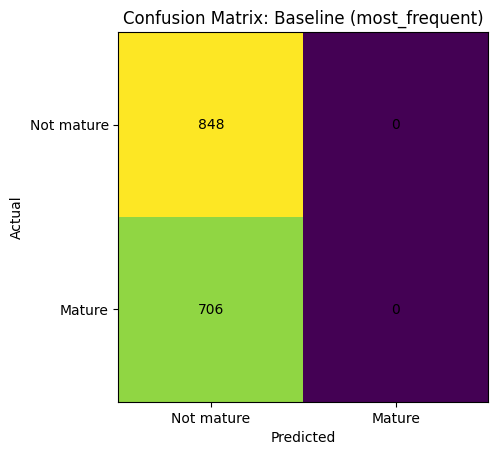

{'model': 'Baseline (most_frequent)',
 'accuracy': 0.5456885456885456,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.4543114543114543}

In [24]:
# =========================
# Step 3 — Baseline model (sanity check)
# =========================
# Baseline: predict the most frequent class.
# This provides a "floor" that my real model should beat.

baseline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=42))
])

baseline.fit(X_train, y_train)
baseline_metrics = evaluate_classifier(baseline, X_test, y_test, name='Baseline (most_frequent)')
baseline_metrics



=== Logistic Regression — classification report ===
              precision    recall  f1-score   support

           0      0.784     0.728     0.755       848
           1      0.699     0.759     0.728       706

    accuracy                          0.742      1554
   macro avg      0.741     0.743     0.741      1554
weighted avg      0.745     0.742     0.742      1554

Confusion matrix [ [TN, FP], [FN, TP] ]:
[[617 231]
 [170 536]]


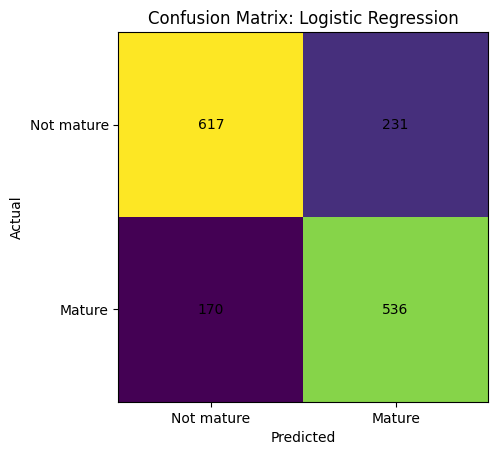

{'model': 'Logistic Regression',
 'accuracy': 0.741956241956242,
 'precision': 0.6988265971316818,
 'recall': 0.7592067988668555,
 'f1': 0.7277664630006789,
 'roc_auc': 0.8231173833449142,
 'pr_auc': 0.7660518760185953}

In [25]:
# =========================
# Step 4 — Model 1: Logistic Regression (primary model)
# =========================
# Why Logistic Regression:
# - Strong baseline for sparse + one-hot features
# - Interpretable coefficients
# - With class_weight='balanced', it can handle class imbalance better

log_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)
logreg_metrics = evaluate_classifier(log_reg, X_test, y_test, name='Logistic Regression')
logreg_metrics


In [26]:
# =========================
# Step 5 — Compare models in a small table
# =========================
results = pd.DataFrame([baseline_metrics, logreg_metrics])
results


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline (most_frequent),0.545689,0.000000,0.000000,0.000000,0.500000,0.454311
1,Logistic Regression,0.741956,0.698827,0.759207,0.727766,0.823117,0.766052


In [27]:
from IPython.display import display

# =========================
# Step 6 — Interpreting the Logistic Regression model (feature drivers)
# =========================
# I extract the largest positive and negative coefficients to see which features push predictions toward mature vs not.
# This helps me connect results back to the business goal (why titles get flagged).

clf = log_reg.named_steps['clf']
coefs = clf.coef_.ravel()

# Get feature names from preprocessing (best-effort)
try:
    feature_names = log_reg.named_steps['preprocess'].get_feature_names_out()
except Exception as e:
    print('Could not get feature names automatically:', e)
    feature_names = np.array([f'feature_{i}' for i in range(len(coefs))])

# Safety: if something still mismatches, fall back to generic names so we still show interpretability output
if len(feature_names) != len(coefs):
    print(f'Feature name length ({len(feature_names)}) does not match coefficients ({len(coefs)}). Using generic names.')
    feature_names = np.array([f'feature_{i}' for i in range(len(coefs))])

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs}).sort_values('coef')

print('\nTop features pushing toward NOT mature (most negative):')
display(coef_df.head(15))

print('\nTop features pushing toward MATURE (most positive):')
display(coef_df.tail(15))



Top features pushing toward NOT mature (most negative):


,feature,coef
68,genres__children & family movies,-4.504309
82,genres__kids' tv,-4.237486
77,genres__faith & spirituality,-2.573604
46,country__pakistan,-1.715268
33,country__india,-1.473117
91,genres__science & nature tv,-1.317160
34,country__indonesia,-1.239567
85,genres__movies,-1.221983
40,country__malaysia,-1.100034
103,genres__tv sci-fi & fantasy,-0.934027



Top features pushing toward MATURE (most positive):


,feature,coef
104,genres__tv thrillers,0.867621
19,country__argentina,0.892702
84,genres__lgbtq movies,0.903968
0,num__release_year,0.927281
73,genres__cult movies,0.929824
21,country__belgium,0.950294
72,genres__crime tv shows,0.965297
78,genres__horror movies,0.986135
99,genres__tv comedies,0.996210
54,country__spain,1.150600


## Overview / Conclusion (insights gained)

Based on the evaluation results above, I interpret the model in terms of the project goal: **flagging mature titles early so they can be reviewed or routed appropriately**.

- **Recall** tells me how many mature titles the model successfully catches (important for parental-control safety).
- **Precision** tells me how “clean” my review queue is (important so reviewers are not overwhelmed).
- **F1 score** summarizes the tradeoff between precision and recall.
- **ROC-AUC and PR-AUC** indicate how well the model ranks mature titles above non-mature titles across thresholds.

### Practical takeaway
If the Logistic Regression model improves meaningfully over the baseline (especially on **recall and F1**), it shows that Netflix metadata contains useful signals for detecting mature content.



# Final Project Updates Since Milestone 3

This section was added for the final project submission.

## New content added after Milestone 3
- ROC and Precision-Recall visualizations
- Threshold analysis for precision/recall trade-offs
- Final deployment-readiness discussion
- Recommendations and future work

These additions make the final notebook comply with the instruction to add new code and/or analysis and clearly note what was added since Milestone 3.


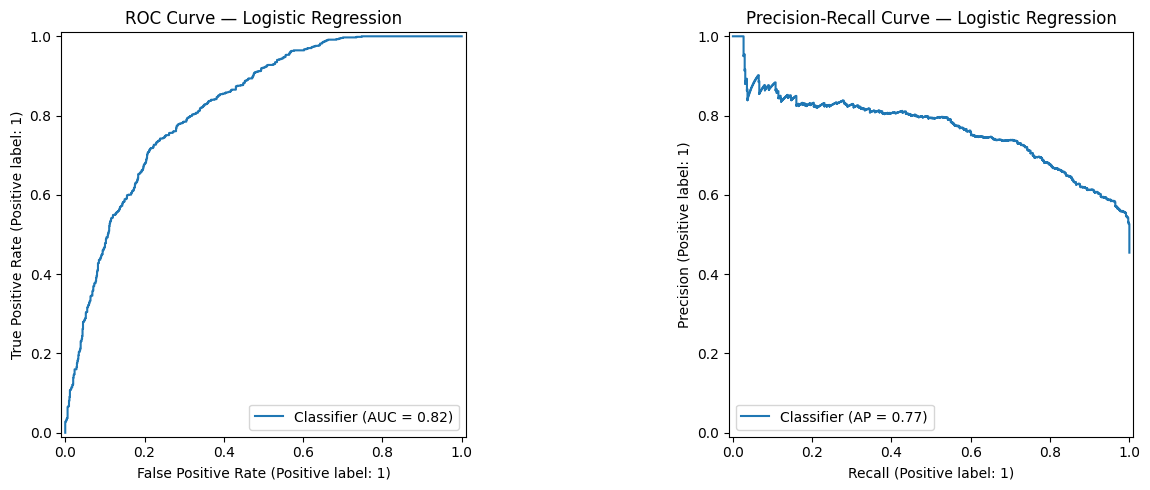

In [28]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, precision_score, recall_score, f1_score

# Final Project Update 1: ROC and Precision-Recall curves
y_score = log_reg.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_test, y_score, ax=ax[0])
ax[0].set_title("ROC Curve — Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=ax[1])
ax[1].set_title("Precision-Recall Curve — Logistic Regression")
plt.tight_layout()
plt.show()


In [29]:
# Final Project Update 2: Threshold analysis
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []

for t in thresholds:
    y_pred_t = (y_score >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_results = pd.DataFrame(rows)
threshold_results


,threshold,precision,recall,f1
0,0.3,0.590586,0.941926,0.725983
1,0.4,0.634937,0.859773,0.730445
2,0.5,0.698827,0.759207,0.727766
3,0.6,0.750883,0.601983,0.668239
4,0.7,0.798054,0.464589,0.587287


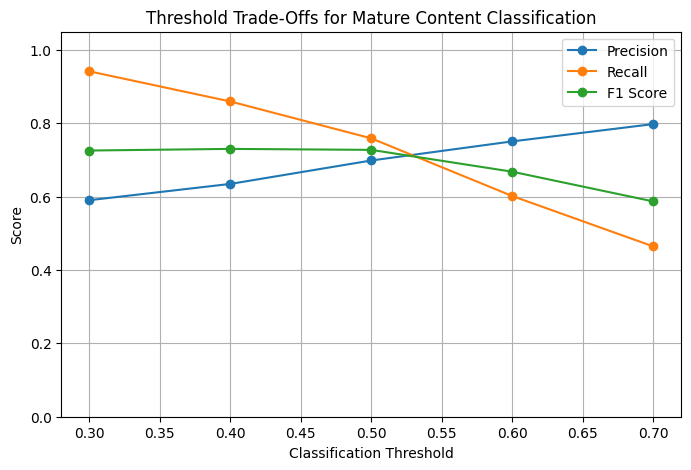

In [30]:
# Final Project Update 3: Plot threshold trade-offs
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1 Score")
plt.title("Threshold Trade-Offs for Mature Content Classification")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


# 
Final Project Conclusion

## What the analysis and model building tell me
The analysis shows that Netflix metadata contains useful signals for predicting whether a title is mature content. The exploratory analysis, preparation steps, and model results together support the project goal.

## Is this model ready to be deployed?
Not yet as a full production model. It is a strong proof of concept, but it still needs additional validation, tuning, and testing on newer or external data.

## Recommendations
- Use the model as a decision-support tool
- Prioritize recall if missing mature titles is the biggest concern
- Add text-based features such as description analysis
- Test additional model types and tune hyperparameters

## Challenges and future opportunities
Possible challenges include missing metadata, changing catalog patterns over time, and rating inconsistencies. Future work could include NLP, stronger feature engineering, and integration into recommendation or parental-control workflows.
